In [3]:
# A system that can automatically fetch, clean, store, and visualize financial market data in a scalable and reusable manner.
!pip install yfinance pandas matplotlib plotly

Defaulting to user installation because normal site-packages is not writeable


In [48]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [49]:
#data fetching of aaple inc from yahoo finance 
ticker = "AAPL"

data = yf.download(ticker, period="10y")

data.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-11,24.690899,25.051004,24.647869,24.679576,117630000
2016-04-12,25.012501,25.026089,24.609366,24.763371,108929200
2016-04-13,25.374874,25.442817,25.094039,25.094039,133029200
2016-04-14,25.388456,25.454136,25.214067,25.279747,101895600
2016-04-15,24.878880,25.433758,24.851703,25.390726,187756000


In [50]:
data.columns = data.columns.droplevel(1)

In [51]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2514 entries, 2016-04-11 to 2026-04-09
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2514 non-null   float64
 1   High    2514 non-null   float64
 2   Low     2514 non-null   float64
 3   Open    2514 non-null   float64
 4   Volume  2514 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.8 KB
None
Price        Close         High          Low         Open        Volume
count  2514.000000  2514.000000  2514.000000  2514.000000  2.514000e+03
mean    120.505038   121.708282   119.191677   120.403014  9.826010e+07
std      75.333083    76.066069    74.543347    75.283057  5.595023e+07
min      20.584810    20.887864    20.386574    20.507340  1.791060e+07
25%      44.138610    44.423818    43.802983    44.126973  5.904458e+07
50%     126.975464   127.957391   124.932784   126.321098  8.631980e+07
75%     176.425690   177.786717   174.497852   176.11058

In [52]:
#introduces NaNs
data = data.dropna()

In [53]:
# Returns
data['Returns'] = data['Close'].pct_change()

# Moving averages
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

data.head()

Price,Close,High,Low,Open,Volume,Returns,MA50,MA200
Date,,,,,,,,
2016-04-11,24.690899,25.051004,24.647869,24.679576,117630000,NaN,NaN,NaN
2016-04-12,25.012501,25.026089,24.609366,24.763371,108929200,0.013025,NaN,NaN
2016-04-13,25.374874,25.442817,25.094039,25.094039,133029200,0.014488,NaN,NaN
2016-04-14,25.388456,25.454136,25.214067,25.279747,101895600,0.000535,NaN,NaN
2016-04-15,24.878880,25.433758,24.851703,25.390726,187756000,-0.020071,NaN,NaN


In [54]:
# Moving averages
data['MA50'] = data['Close'].rolling(50).mean()
data['MA200'] = data['Close'].rolling(200).mean()

# Returns (ADD THIS)
data['Returns'] = data['Close'].pct_change()

# RSI
delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

# Volatility
data['Volatility'] = data['Returns'].rolling(20).std()

# CLEAN DATA
data = data.dropna()

# Signals
data['Signal'] = 0
data.loc[data['MA50'] > data['MA200'], 'Signal'] = 1
data['Position'] = data['Signal'].diff()

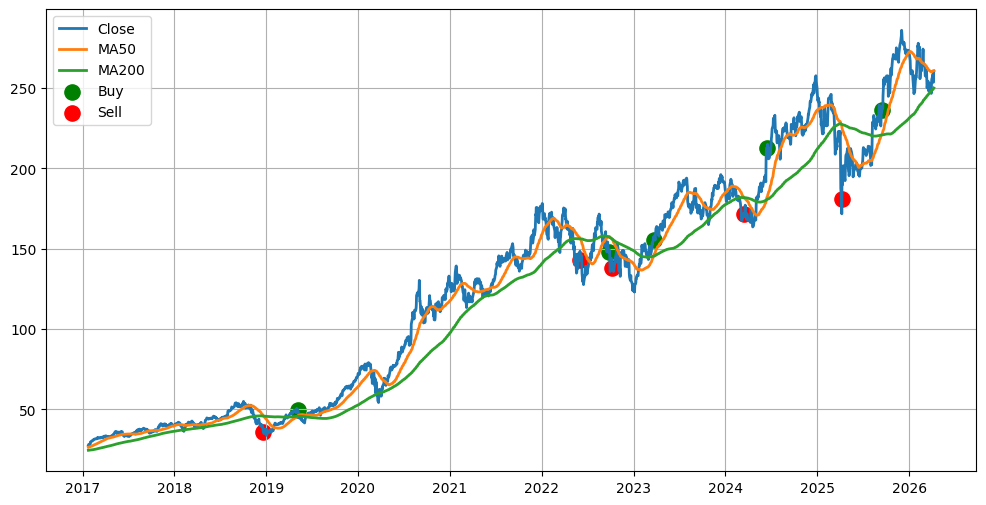

In [55]:
plt.figure(figsize=(12,6))

plt.plot(data['Close'], label='Close', linewidth=2)
plt.plot(data['MA50'], label='MA50', linewidth=2)
plt.plot(data['MA200'], label='MA200', linewidth=2)

# Buy
plt.scatter(data.index[data['Position'] == 1],
            data['Close'][data['Position'] == 1],
            color='green', label='Buy', s=120)

# Sell
plt.scatter(data.index[data['Position'] == -1],
            data['Close'][data['Position'] == -1],
            color='red', label='Sell', s=120)

plt.legend()
plt.grid()
plt.show()

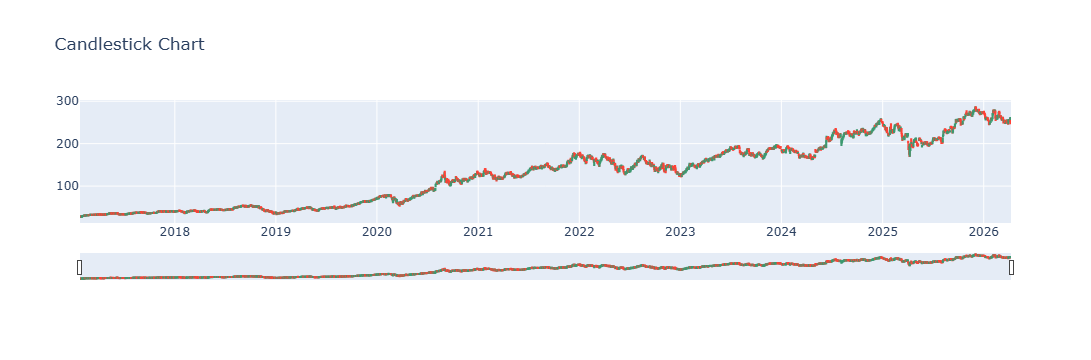

In [56]:
fig = go.Figure(data=[go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close']
)])

fig.update_layout(title="Candlestick Chart")

fig.show()